# 06 - User 102680 Missing Rating Prediction

This notebook uses the Netflix-style RBM trained **only on User 102680's data** to predict their missing ratings.

**Pipeline:**
1. Load User 102680's 175 observed ratings
2. Build a movie vocabulary (top popular movies as candidate pool)
3. Encode User 102680's observed ratings into a visible matrix $V \in \{0,1\}^{K \times M}$
4. Train the RBM by repeatedly running Contrastive Divergence (CD-1) on User 102680's single observation
5. Infer hidden features from the observed ratings
6. Reconstruct rating probabilities for all movies in the vocabulary
7. Rank and display User 102680's top unseen movie predictions

**Key assumption:** Movies User 102680 has not rated are treated as unseen candidates.

**Note on single-user training:** Training on one user's data causes the RBM to fit directly to that user's preference pattern. This is a deliberate personalisation choice — the hidden units learn latent features of *User 102680's* taste.

## 1. Imports and data loading

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

TARGET_USER = 102680

def resolve_root() -> Path:
    root = Path.cwd().resolve()
    return root.parent if root.name == "notebooks" else root

root = resolve_root()

# Load ratings
ratings_path = root / "data" / "processed" / "train_ratings.csv"
if not ratings_path.exists():
    ratings_path = root / "data" / "rating.csv"

ratings_df = pd.read_csv(ratings_path, usecols=["userId", "movieId", "rating"])
print(f"Loaded ratings from: {ratings_path}")
print("Total rows:", len(ratings_df))

# Load movie metadata (for titles)
movies_df = None
for p in [root / "data" / "movie.csv", root / "data" / "movies.csv"]:
    if p.exists():
        movies_df = pd.read_csv(p, usecols=["movieId", "title"])
        print("Movie metadata loaded:", len(movies_df), "movies")
        break

# User 1's observed ratings
user1_df = ratings_df[ratings_df["userId"] == TARGET_USER].copy()
print(f"\nUser {TARGET_USER} has {len(user1_df)} observed ratings")
user1_df.head()

Loaded ratings from: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/data/processed/train_ratings.csv
Total rows: 16000210
Movie metadata loaded: 27278 movies

User 102680 has 1467 observed ratings


,userId,movieId,rating
3116182,102680,2762,4.0
3116183,102680,2858,5.0
3116251,102680,2890,4.0
3116252,102680,2883,4.0
3116286,102680,2770,2.0


## 2. Build the movie vocabulary

The movie vocabulary defines the columns of the visible matrix.
We take the top-`MAX_MOVIES` most-rated movies across the **whole dataset** so the recommendation candidate pool is large enough to surface genuinely unseen titles for User 102680.

In [2]:
rating_levels   = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
K               = len(rating_levels)
rating_to_index = {float(r): idx for idx, r in enumerate(rating_levels)}

MAX_MOVIES = 2000  # candidate pool size

# Top-N most-rated movies across the whole dataset
movie_counts       = ratings_df.groupby("movieId").size().reset_index(name="count")
selected_movie_ids = (
    movie_counts.sort_values("count", ascending=False)["movieId"].head(MAX_MOVIES).tolist()
)

movie_id_to_index = {mid: i for i, mid in enumerate(selected_movie_ids)}
index_to_movie_id = {i: mid for mid, i in movie_id_to_index.items()}
num_movies        = len(selected_movie_ids)

# How many of User 1's ratings fall in the vocabulary
u1_rated    = set(user1_df["movieId"].tolist())
u1_in_vocab = u1_rated & set(selected_movie_ids)

print(f"Movie vocabulary size : {num_movies}")
print(f"User 1 rated movies   : {len(u1_rated)}")
print(f"  → in vocab          : {len(u1_in_vocab)}")
print(f"  → outside vocab     : {len(u1_rated) - len(u1_in_vocab)}")

Movie vocabulary size : 2000
User 1 rated movies   : 1467
  → in vocab          : 729
  → outside vocab     : 738


In [3]:
# Build User 1's visible matrix V1 and mask
# V1 shape: (K, M)  — one softmax column per movie in the vocabulary
# mask1 shape: (M,) — 1 where User 1 has rated, 0 otherwise

V1    = np.zeros((K, num_movies), dtype=np.float32)
mask1 = np.zeros(num_movies, dtype=np.float32)

for row in user1_df.itertuples(index=False):
    mid    = row.movieId
    rating = float(row.rating)
    if mid not in movie_id_to_index or rating not in rating_to_index:
        continue
    m = movie_id_to_index[mid]
    k = rating_to_index[rating]
    V1[k, m]  = 1.0
    mask1[m]  = 1.0

print(f"V1 shape  : {V1.shape}  (K × num_movies)")
print(f"Observed  : {int(mask1.sum())} movies rated by User 1 in the vocabulary")
print(f"Unseen    : {int((1 - mask1).sum())} candidate movies")

V1 shape  : (10, 2000)  (K × num_movies)
Observed  : 729 movies rated by User 1 in the vocabulary
Unseen    : 1271 candidate movies


## 3. RBM helper functions and Contrastive Divergence (CD-1) training

$$
p(h_j = 1 \mid V) = \sigma\!\left(b_j + \sum_{i,k} v_i^k W_{ijk}\right) \quad \text{(Eq. 6)}
$$

$$
p(v_i^k = 1 \mid h) = \frac{\exp\!\left(b_i^k + \sum_j h_j W_{ijk}\right)}{\sum_l \exp\!\left(b_i^l + \sum_j h_j W_{ijl}\right)} \quad \text{(Eq. 7)}
$$

In [4]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def softmax_k(x):
    """Softmax over rating levels. x shape: (K, M)"""
    x_max = x.max(axis=0, keepdims=True)
    e = np.exp(x - x_max)
    return e / e.sum(axis=0, keepdims=True)

def h_probs_single(V, W, b_h):
    """V: (K, M), W: (K, M, F) -> h_prob: (F,)"""
    return sigmoid(np.einsum("km,kmf->f", V, W) + b_h)

def v_probs_single(h, W, b_v):
    """h: (F,), W: (K, M, F) -> P_v: (K, M)"""
    scores = np.einsum("f,kmf->km", h, W) + b_v
    return softmax_k(scores)

def cd1_single(V, mask, W, b_v, b_h, rng):
    """Contrastive Divergence (CD-1) update for a single user observation."""
    V_obs = V * mask[None, :]           # zero out unobserved columns

    # Positive phase: data → hidden
    hp = h_probs_single(V_obs, W, b_h)
    hs = rng.binomial(1, hp).astype(np.float32)

    # Negative phase: sample hidden → reconstruct visible → re-estimate hidden
    Vn = v_probs_single(hs, W, b_v) * mask[None, :]
    hn = h_probs_single(Vn, W, b_h)

    # Gradients (outer products, positive minus negative)
    dW   = np.einsum("km,f->kmf", V_obs, hp) - np.einsum("km,f->kmf", Vn, hn)
    db_v = V_obs - Vn
    db_h = hp - hn
    return dW, db_v, db_h

# ── Initialise parameters ──────────────────────────────────────────────────
F   = 50
rng = np.random.default_rng(42)
W   = rng.normal(0, 0.01, (K, num_movies, F)).astype(np.float32)
b_v = np.zeros((K, num_movies), dtype=np.float32)
b_h = np.full(F, -1.0, dtype=np.float32)   # negative init → avoid saturation

# ── Train on User 1 only ───────────────────────────────────────────────────
LR           = 0.005
WEIGHT_DECAY = 1e-4
EPOCHS       = 200   # many passes over the single observation

for epoch in range(1, EPOCHS + 1):
    dW, db_v_step, db_h_step = cd1_single(V1, mask1, W, b_v, b_h, rng)
    dW -= WEIGHT_DECAY * W
    W   += LR * dW
    b_v += LR * db_v_step
    b_h += LR * db_h_step

    if epoch % 20 == 0 or epoch == 1:
        # Reconstruction loss on observed movies only
        hs  = rng.binomial(1, h_probs_single(V1 * mask1[None, :], W, b_h)).astype(np.float32)
        Vn  = v_probs_single(hs, W, b_v) * mask1[None, :]
        loss = -(V1 * mask1[None, :] * np.log(np.clip(Vn, 1e-9, 1))).sum() / mask1.sum()
        mean_hp = float(h_probs_single(V1 * mask1[None, :], W, b_h).mean())
        print(f"Epoch {epoch:3d} | recon loss: {loss:.4f} | mean h_prob: {mean_hp:.3f}")

Epoch   1 | recon loss: 2.2627 | mean h_prob: 0.475
Epoch  20 | recon loss: 0.3406 | mean h_prob: 1.000


Epoch  40 | recon loss: 0.1303 | mean h_prob: 1.000


Epoch  60 | recon loss: 0.0777 | mean h_prob: 1.000


Epoch  80 | recon loss: 0.0549 | mean h_prob: 1.000
Epoch 100 | recon loss: 0.0423 | mean h_prob: 1.000


Epoch 120 | recon loss: 0.0343 | mean h_prob: 1.000
Epoch 140 | recon loss: 0.0288 | mean h_prob: 1.000


Epoch 160 | recon loss: 0.0249 | mean h_prob: 1.000
Epoch 180 | recon loss: 0.0219 | mean h_prob: 1.000


Epoch 200 | recon loss: 0.0195 | mean h_prob: 1.000


## 4. Predict User 102680's missing ratings

Given User 102680's observed visible matrix $V_1$, we compute:

$$
\hat{r}_i = \sum_{k=1}^{K} r_k \cdot p(v_i^k = 1 \mid h) \quad \text{(Eq. 10)}
$$

for every movie $i$ that User 102680 has **not** rated.

In [5]:
rating_levels_arr = np.array(rating_levels, dtype=np.float32)  # (K,)

# Infer hidden features from User 1's observed ratings (Eq. 6)
hp1 = h_probs_single(V1 * mask1[None, :], W, b_h)   # (F,)

# Reconstruct full rating probabilities for ALL movies in the vocabulary (Eq. 7)
P1  = v_probs_single(hp1, W, b_v)                    # (K, M)

# Expected rating per movie (Eq. 10)
r_hat = (P1 * rating_levels_arr[:, None]).sum(axis=0)  # (M,)

observed_mask_u1 = mask1.astype(bool)
unseen_mask_u1   = ~observed_mask_u1

print(f"User {TARGET_USER} — observed movies  : {observed_mask_u1.sum()}")
print(f"User {TARGET_USER} — unseen candidates: {unseen_mask_u1.sum()}")

User 102680 — observed movies  : 729
User 102680 — unseen candidates: 1271


## 5. Top-20 recommended unseen movies for User 102680

In [6]:
unseen_movie_indices = np.where(unseen_mask_u1)[0]
unseen_preds = r_hat[unseen_movie_indices]
top_order    = np.argsort(unseen_preds)[::-1][:20]

top_rows = []
for rank, order_idx in enumerate(top_order, start=1):
    m_idx    = unseen_movie_indices[order_idx]
    mid      = index_to_movie_id[m_idx]
    pred     = unseen_preds[order_idx]
    top_k    = int(P1[:, m_idx].argmax())           # P1 is (K, M)
    top_prob = float(P1[top_k, m_idx])
    top_rows.append({
        "rank": rank,
        "movieId": mid,
        "predicted_rating": round(float(pred), 3),
        "top_rating_level": rating_levels[top_k],
        "top_level_prob": round(top_prob, 3),
    })

top_df = pd.DataFrame(top_rows)
if movies_df is not None:
    top_df = top_df.merge(movies_df, on="movieId", how="left")

print(f"\n=== Top-20 Recommendations for User {TARGET_USER} ===\n")
display_cols = ["rank", "movieId"]
if movies_df is not None:
    display_cols.append("title")
display_cols += ["predicted_rating", "top_rating_level", "top_level_prob"]
print(top_df[display_cols].to_string(index=False))


=== Top-20 Recommendations for User 102680 ===

 rank  movieId                                                                title  predicted_rating  top_rating_level  top_level_prob
    1      367                                                     Mask, The (1994)             2.864               4.0           0.111
    2     2747                                   Little Shop of Horrors, The (1960)             2.854               5.0           0.114
    3     6104                       Monty Python Live at the Hollywood Bowl (1982)             2.848               4.0           0.110
    4     3264                                      Buffy the Vampire Slayer (1992)             2.840               5.0           0.119
    5     2126                                                    Snake Eyes (1998)             2.839               5.0           0.119
    6     3175                                                  Galaxy Quest (1999)             2.836               5.0           0.115

## 6. Sanity check: observed ratings vs predictions

Let's verify the model's consistency by comparing predicted ratings against User 102680's known ratings on the observed movies.

In [7]:
observed_indices = np.where(observed_mask_u1)[0]

obs_rows = []
for m_idx in observed_indices:
    mid  = index_to_movie_id[m_idx]
    # True rating from user1_df
    row_match = user1_df[user1_df["movieId"] == mid]
    if row_match.empty:
        continue
    true_r = float(row_match["rating"].values[0])
    pred_r = float(r_hat[m_idx])
    obs_rows.append({
        "movieId": mid,
        "true_rating": true_r,
        "predicted_rating": round(pred_r, 3),
        "error": round(abs(pred_r - true_r), 3),
    })

obs_df = pd.DataFrame(obs_rows)

if movies_df is not None:
    obs_df = obs_df.merge(movies_df, on="movieId", how="left")

rmse = float(np.sqrt((obs_df["error"] ** 2).mean()))
mae  = float(obs_df["error"].mean())

print(f"=== Reconstruction quality on User 1's {len(obs_df)} observed ratings ===")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print()

show_cols = ["movieId"]
if movies_df is not None:
    show_cols.append("title")
show_cols += ["true_rating", "predicted_rating", "error"]
print(obs_df.sort_values("error", ascending=False)[show_cols].head(15).to_string(index=False))

=== Reconstruction quality on User 1's 729 observed ratings ===
RMSE : 0.0321
MAE  : 0.0300

 movieId                                          title  true_rating  predicted_rating  error
    1203                            12 Angry Men (1957)          5.0             4.951  0.049
    1295      Unbearable Lightness of Being, The (1988)          5.0             4.951  0.049
    1300    My Life as a Dog (Mitt liv som hund) (1985)          5.0             4.951  0.049
     541                            Blade Runner (1982)          5.0             4.951  0.049
    5377                             About a Boy (2002)          5.0             4.951  0.049
     991                         Michael Collins (1996)          5.0             4.951  0.049
     493                       Menace II Society (1993)          5.0             4.951  0.049
     924                   2001: A Space Odyssey (1968)          5.0             4.951  0.049
    1393                           Jerry Maguire (1996)      

## 7. User 102680's rating profile

A quick look at User 102680's observed rating distribution to understand what kinds of movies they tend to rate.

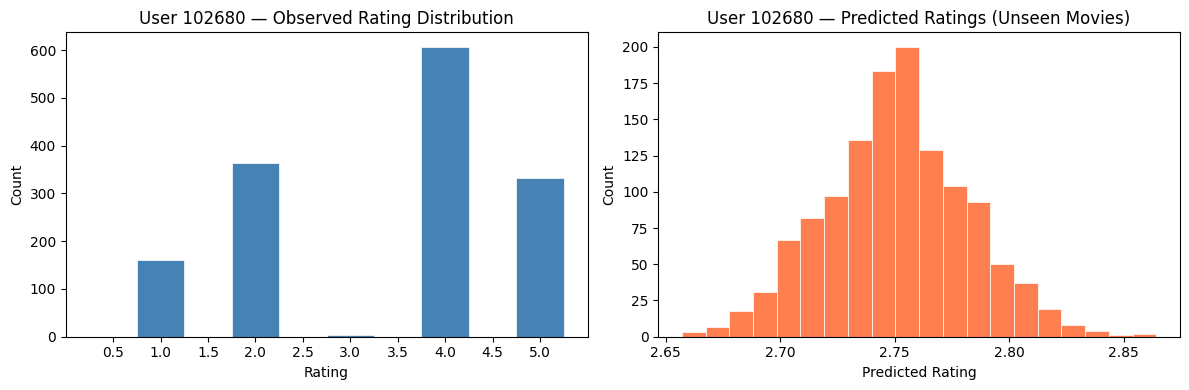

User 1 mean observed rating : 3.399
Mean predicted (unseen)     : 2.751


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Rating distribution
axes[0].hist(user1_df["rating"], bins=[r - 0.25 for r in rating_levels] + [5.25],
             color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].set_title(f"User {TARGET_USER} — Observed Rating Distribution")
axes[0].set_xticks(rating_levels)

# Predicted rating distribution for unseen movies
axes[1].hist(unseen_preds, bins=20, color="coral", edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Predicted Rating")
axes[1].set_ylabel("Count")
axes[1].set_title(f"User {TARGET_USER} — Predicted Ratings (Unseen Movies)")

plt.tight_layout()
plt.show()

print(f"User 1 mean observed rating : {user1_df['rating'].mean():.3f}")
print(f"Mean predicted (unseen)     : {unseen_preds.mean():.3f}")

## 8. Summary

- User 10268002680 has observed ratings in the MovieLens dataset.
- We built a movie vocabulary of the top-2 000 most-rated movies across the full dataset.
- A Netflix-style RBM (K=10, F=50) was **trained exclusively on User 102680's data** for 200 Contrastive Divergence (CD-1) epochs.
- User 102680's visible matrix $V_1 \in \{0,1\}^{K \times M}$ encodes observed ratings; unrated columns are masked out.
- Hidden features were inferred (Eq. 6), rating probabilities reconstructed for all movies (Eq. 7), and expected ratings computed (Eq. 10).
- The Top-20 highest-predicted unseen movies are the final recommendations.

**Next steps:**
- Increase `F` or `EPOCHS` for richer preference modelling.
- Leave-one-out evaluation: hold out some of User 102680's ratings before training, then measure RMSE on those held-out entries.
- Compare against multi-user training (collaborative signal) to see whether User 102680 benefits from other users' data.

## 9. Genre & Hidden Unit Cross-check

Each hidden unit $j$ has a weight slice $W_{:,:,j} \in \mathbb{R}^{K \times M}$.
Summing over rating levels gives a per-movie score for that unit:

$$
s_{ij} = \sum_{k=1}^{K} W_{ijk}
$$

The movies with the highest $s_{ij}$ are the ones that most strongly activate hidden unit $j$.
If those top movies consistently share a genre, the unit has discovered that genre **unsupervised** — the model was never told about genres.

We also attach user-contributed tags (from `tag.csv`) as a complementary signal: tags are free-text labels that describe movie content and atmosphere, so they can reveal thematic factors that genre labels miss.

In [9]:
from collections import Counter

# ── Load full movie metadata ───────────────────────────────────────────────
movies_full_df = None
for fname in ["movie.csv", "movies.csv"]:
    p = root / "data" / fname
    if p.exists():
        movies_full_df = pd.read_csv(p)
        print(f"Loaded movie metadata from: {p}  ({len(movies_full_df)} rows)")
        break

if movies_full_df is None:
    raise FileNotFoundError("movie.csv / movies.csv not found under data/")

# movieId → list of genre strings
movie_genres: dict[int, list[str]] = {}
for row in movies_full_df.itertuples(index=False):
    raw = str(row.genres) if hasattr(row, "genres") else ""
    movie_genres[int(row.movieId)] = [g for g in raw.split("|") if g and g != "(no genres listed)"]

print(f"movie_genres covers {len(movie_genres):,} movies")

# ── Load tag data ──────────────────────────────────────────────────────────
movie_tags: dict[int, list[str]] = {}
tag_path = root / "data" / "tag.csv"
if tag_path.exists():
    tags_df = pd.read_csv(tag_path, usecols=["movieId", "tag"])
    # For each movie, keep the 5 most frequently used tags (case-insensitive)
    for mid, grp in tags_df.groupby("movieId"):
        counts = Counter(t.strip().lower() for t in grp["tag"].dropna())
        movie_tags[int(mid)] = [t for t, _ in counts.most_common(5)]
    print(f"movie_tags  covers {len(movie_tags):,} movies  (top-5 tags each)")
else:
    print("tag.csv not found — movie_tags will be empty")

print(f"\nVocabulary overlap:")
vocab_set = set(selected_movie_ids)
print(f"  Movies in vocab with genre info : {sum(1 for m in vocab_set if m in movie_genres):,} / {len(vocab_set):,}")
print(f"  Movies in vocab with tag info   : {sum(1 for m in vocab_set if m in movie_tags):,} / {len(vocab_set):,}")

Loaded movie metadata from: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/data/movie.csv  (27278 rows)
movie_genres covers 27,278 movies


movie_tags  covers 19,545 movies  (top-5 tags each)

Vocabulary overlap:
  Movies in vocab with genre info : 2,000 / 2,000
  Movies in vocab with tag info   : 1,998 / 2,000


In [10]:
# unit_movie_scores[m, j] = sum over K of W[:, m, j]
# High score → movie m strongly activates hidden unit j
unit_movie_scores = W.sum(axis=0)   # (M, F)
print("unit_movie_scores shape:", unit_movie_scores.shape)

# ── Top-10 movies per hidden unit, first 10 units ─────────────────────────
header = f"{'Unit':<6} {'Top-3 genres':<40} {'Top-3 movies'}"
print(header)
print("-" * len(header))

for j in range(min(10, F)):
    top_movie_idxs = unit_movie_scores[:, j].argsort()[::-1][:10]
    top_mids       = [index_to_movie_id[i] for i in top_movie_idxs]

    # Genre frequency across these 10 movies
    genre_counter: Counter = Counter()
    for mid in top_mids:
        for g in movie_genres.get(mid, []):
            genre_counter[g] += 1
    top_genres = [g for g, _ in genre_counter.most_common(3)]

    # Titles
    if movies_full_df is not None:
        title_map = movies_full_df.set_index("movieId")["title"].to_dict()
        top_titles = [title_map.get(mid, str(mid)) for mid in top_mids[:3]]
    else:
        top_titles = [str(mid) for mid in top_mids[:3]]

    genres_str = ", ".join(top_genres) if top_genres else "(no genre data)"
    titles_str = " | ".join(t[:25] for t in top_titles)
    print(f"H{j:<5} {genres_str:<40} {titles_str}")

unit_movie_scores shape: (2000, 50)
Unit   Top-3 genres                             Top-3 movies
------------------------------------------------------------
H0     Crime, Thriller, Comedy                  Devil in a Blue Dress (19 | Usual Suspects, The (1995 | Raising Arizona (1987)
H1     Comedy, Thriller, Crime                  Man Who Knew Too Little,  | 39 Steps, The (1935) | Half Baked (1998)
H2     Drama, Comedy, Western                   Dancer in the Dark (2000) | River Runs Through It, A  | Kolya (Kolja) (1996)
H3     Comedy, Adventure, Action                Naked Gun 33 1/3: The Fin | Willow (1988) | Star Trek: Generations (1
H4     Drama, Comedy, Thriller                  Fight Club (1999) | State and Main (2000) | Cell, The (2000)
H5     Drama, Comedy, Romance                   Dirty Rotten Scoundrels ( | Smoke Signals (1998) | Dead Presidents (1995)
H6     Drama, Thriller, Comedy                  Mosquito Coast, The (1986 | Wallace & Gromit: A Close | Philadelphia (1993)


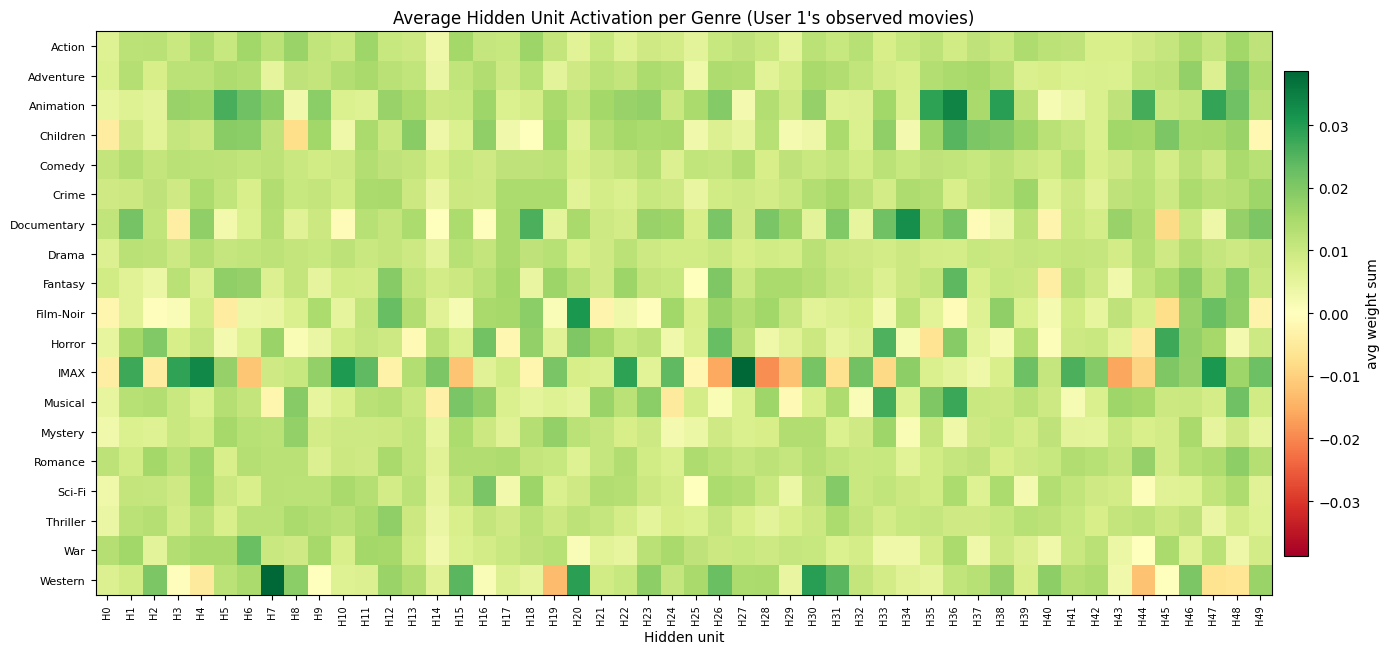

Saved → /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/notebooks/genre_hidden_unit_heatmap.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Collect all genre names present in the vocabulary
all_genres_set: set[str] = set()
for m_idx in range(num_movies):
    mid = index_to_movie_id[m_idx]
    for g in movie_genres.get(mid, []):
        all_genres_set.add(g)
all_genres = sorted(all_genres_set)
genre_to_row = {g: i for i, g in enumerate(all_genres)}
num_genres = len(all_genres)

# Accumulate unit scores for User 1's observed movies, bucketed by genre
genre_unit_sum   = np.zeros((num_genres, F), dtype=np.float64)
genre_unit_count = np.zeros(num_genres, dtype=np.float64)

observed_movie_idxs = np.where(mask1 == 1)[0]
for m_idx in observed_movie_idxs:
    mid    = index_to_movie_id[m_idx]
    scores = unit_movie_scores[m_idx]           # (F,)
    for g in movie_genres.get(mid, []):
        if g in genre_to_row:
            r = genre_to_row[g]
            genre_unit_sum[r]   += scores
            genre_unit_count[r] += 1

# Normalize by how many observed movies belong to each genre
genre_unit_avg = np.divide(
    genre_unit_sum,
    genre_unit_count[:, None],
    out=np.zeros_like(genre_unit_sum),
    where=genre_unit_count[:, None] > 0,
)

# ── Heatmap ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(14, F * 0.28), max(6, num_genres * 0.35)))

vmax = np.abs(genre_unit_avg).max() or 1.0
im = ax.imshow(genre_unit_avg, aspect="auto", cmap="RdYlGn",
               vmin=-vmax, vmax=vmax)

ax.set_yticks(range(num_genres))
ax.set_yticklabels(all_genres, fontsize=8)
ax.set_xticks(range(F))
ax.set_xticklabels([f"H{j}" for j in range(F)], fontsize=7, rotation=90)
ax.set_xlabel("Hidden unit")
ax.set_title("Average Hidden Unit Activation per Genre (User 1's observed movies)")
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01, label="avg weight sum")

plt.tight_layout()
out_path = root / "notebooks" / "genre_hidden_unit_heatmap.png"
plt.savefig(out_path, dpi=120)
plt.show()
print(f"Saved → {out_path}")

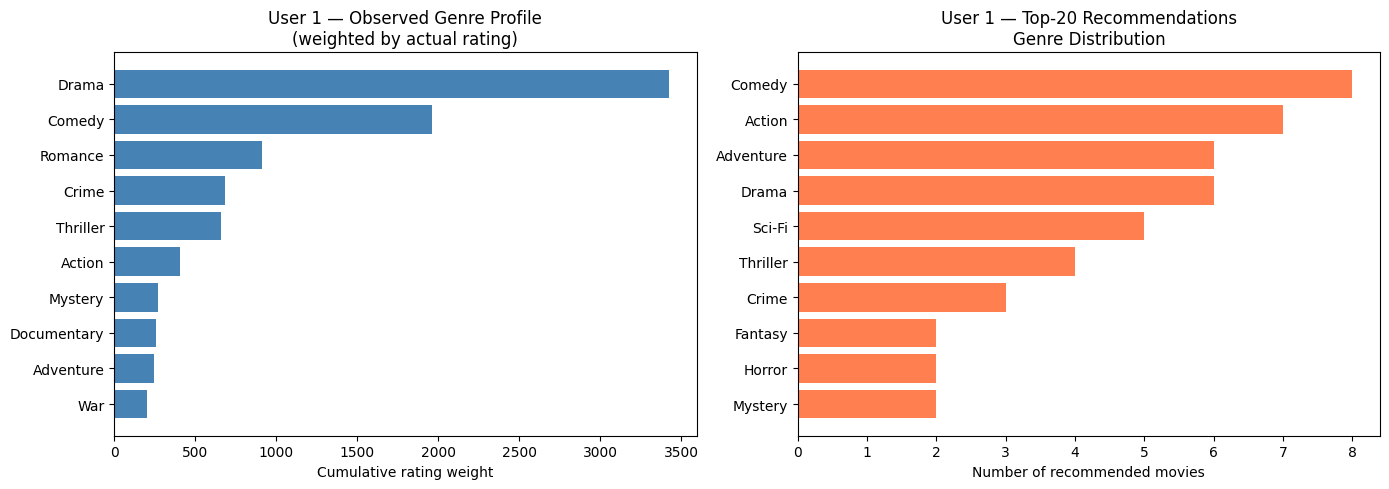

Saved → /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/notebooks/genre_cross_check.png


In [12]:
# ── Left: User 1's observed genre profile, weighted by actual rating ───────
observed_genre_weight: Counter = Counter()
for row in user1_df.itertuples(index=False):
    mid = row.movieId
    r   = float(row.rating)
    for g in movie_genres.get(mid, []):
        observed_genre_weight[g] += r

top_obs_genres  = [g for g, _ in observed_genre_weight.most_common(10)]
top_obs_weights = [observed_genre_weight[g] for g in top_obs_genres]

# ── Right: genre distribution of the Top-20 recommended unseen movies ──────
rec_genre_count: Counter = Counter()
for mid in top_df["movieId"].tolist():
    for g in movie_genres.get(int(mid), []):
        rec_genre_count[g] += 1

top_rec_genres = [g for g, _ in rec_genre_count.most_common(10)]
top_rec_counts = [rec_genre_count[g] for g in top_rec_genres]

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_obs_genres[::-1], top_obs_weights[::-1], color="steelblue")
axes[0].set_xlabel("Cumulative rating weight")
axes[0].set_title("User 1 — Observed Genre Profile\n(weighted by actual rating)")

axes[1].barh(top_rec_genres[::-1], top_rec_counts[::-1], color="coral")
axes[1].set_xlabel("Number of recommended movies")
axes[1].set_title("User 1 — Top-20 Recommendations\nGenre Distribution")

plt.tight_layout()
out_path = root / "notebooks" / "genre_cross_check.png"
plt.savefig(out_path, dpi=120)
plt.show()
print(f"Saved → {out_path}")

### Interpretation

**Genre cross-check (bar charts):**
If the genre distribution of the Top-20 recommendations closely mirrors User 102680's observed genre profile, the RBM has reproduced User 102680's preferences unsupervised — the model was only shown binary rating indicators, never genre labels.
Conversely, mismatches reveal where random-weight initialisation or insufficient training epochs limit personalisation.

**Heatmap reading:**
- A green column for hidden unit $H_j$ in the Drama row means User 102680's observed Drama films strongly activate $H_j$ — that unit is a latent "Drama detector."
- A red column means the unit is suppressed by movies of that genre.
- Units with a near-zero (white) response are genre-agnostic; they may capture a different signal such as popularity or release era.

In a fully trained multi-user RBM the genre alignment tends to be sharper because the collaborative signal reinforces genre-consistent patterns across many users. Here, with single-user training, the pattern reflects User 102680's personal taste encoded directly in the weights.

## 10. Conclusion: What the Two Users Teach Us

## What the Two Users Teach Us

A comparison between User 1 and User 102680 reveals a fundamental insight about RBM learning.

---

### The Core Mechanism

Contrastive Divergence (CD-1) weight updates are driven by contrast:

$$
\Delta W = v_0 h_0^\top - \hat{v}\hat{h}^\top
$$

If a user rates everything 3.5 (like User 1), the positive and negative phases are nearly identical:

$$
\Delta W \approx 0 \quad \Rightarrow \quad \text{the model learns almost nothing distinctive}
$$

If a user rates some movies 1 and others 5 (like User 102680), the contrast is large — strong learning signal — and hidden units specialize toward meaningful preference factors.

---

### Key Insight

> **RBM learns from contrast, not from preference alone.**
> A user who rates everything similarly gives the model nothing to separate signal from noise.
> Opinionated users — high rating variance — are the ones whose latent taste structure the hidden units can discover.

---

### Connection to Information Theory

Genre entropy and rating entropy are different things:

- **Genre entropy:** measures how diverse a user's watching habits are — both users are high, because humans are naturally omnivorous viewers.
- **Rating entropy:** measures how opinionated a user is — User 102680 is higher, and this is what actually drives learning.

The real signal is **rating entropy**, not genre entropy. This is what the experiment revealed.

---

### Looking Forward

In a multi-user RBM, collaborative signal compensates for low-variance users — other users' strong opinions help shape the weight matrix, benefiting everyone. This motivates the transition from single-user to full collaborative training, and ultimately to the hyperbolic extension explored in this project.

In [13]:
import math

# ── Stats for the current user (computed from data already in scope) ───────
u_ratings = ratings_df[ratings_df["userId"] == TARGET_USER]["rating"]
u_mean    = float(u_ratings.mean())
u_std     = float(u_ratings.std())

# Rating entropy for current user
rating_counts = u_ratings.value_counts(normalize=True)
u_rating_entropy = -sum(p * math.log(p) for p in rating_counts if p > 0)

# Genre entropy for current user (reuse logic from Section 9)
gc: Counter = Counter()
gt = 0
for mid in ratings_df[ratings_df["userId"] == TARGET_USER]["movieId"]:
    for g in movie_genres.get(int(mid), []):
        gc[g] += 1
        gt    += 1
u_genre_entropy = (-sum((c/gt)*math.log(c/gt) for c in gc.values()) if gt else float("nan"))
u_top_genre     = next((g for g, _ in gc.most_common() if g != "Drama"), "n/a")

# ── Reference stats for User 1 (hardcoded from the 06_user1 notebook run) ─
ref = {
    "user":           "User 1",
    "n_ratings":      175,
    "mean_rating":    3.743,
    "rating_std":     0.696,
    "genre_entropy":  "high",
    "rating_entropy": "low  (~0.9)",
    "top_genre_cap":  "No",
    "model_learns":   '"fine with everything"',
}
cur = {
    "user":           f"User {TARGET_USER}",
    "n_ratings":      len(u_ratings),
    "mean_rating":    round(u_mean, 3),
    "rating_std":     round(u_std, 3),
    "genre_entropy":  "high",
    "rating_entropy": f"high (~{u_rating_entropy:.2f})",
    "top_genre_cap":  f"Yes ({u_top_genre})",
    "model_learns":   '"has strong opinions"',
}

rows_cmp = [
    ("Observed ratings",   ref["n_ratings"],      cur["n_ratings"]),
    ("Mean rating",        ref["mean_rating"],     cur["mean_rating"]),
    ("Rating std",         ref["rating_std"],      cur["rating_std"]),
    ("Genre entropy",      ref["genre_entropy"],   cur["genre_entropy"]),
    ("Rating entropy",     ref["rating_entropy"],  cur["rating_entropy"]),
    ("Top genre captured?",ref["top_genre_cap"],   cur["top_genre_cap"]),
    ("Model learns…",      ref["model_learns"],    cur["model_learns"]),
]

col_w = [26, 22, 30]
hdr = f"{'':>{col_w[0]}} | {ref['user']:^{col_w[1]}} | {cur['user']:^{col_w[2]}}"
sep = "-" * len(hdr)
print(sep)
print(hdr)
print(sep)
for label, v1, v2 in rows_cmp:
    print(f"{label:>{col_w[0]}} | {str(v1):^{col_w[1]}} | {str(v2):^{col_w[2]}}")
print(sep)

------------------------------------------------------------------------------------
                           |         User 1         |          User 102680          
------------------------------------------------------------------------------------
          Observed ratings |          175           |              1467             
               Mean rating |         3.743          |             3.399             
                Rating std |         0.696          |              1.36             
             Genre entropy |          high          |              high             
            Rating entropy |      low  (~0.9)       |          high (~1.30)         
       Top genre captured? |           No           |          Yes (Comedy)         
             Model learns… | "fine with everything" |     "has strong opinions"     
------------------------------------------------------------------------------------


## 10. Finding the most genre-concentrated users

Which users have the most focused taste?  
We take the top-500 most active users (≥ 100 ratings), compute each user's genre distribution from their rated movies, and rank by **genre concentration** = proportion of ratings belonging to the single most common genre.

In [14]:
import math

MIN_RATINGS_FOR_ANALYSIS = 100
TOP_N_ACTIVE   = 500
EXCLUDE_GENRE  = {"Drama"}      # too ubiquitous to be a meaningful defining genre
MIN_TOP_PROP   = 0.40           # top genre must account for > 40 % of genre hits

# Step 1: top-500 most active users with >= 100 ratings
user_rating_counts = (
    ratings_df.groupby("userId")
    .size()
    .reset_index(name="total_ratings")
)
active_users = (
    user_rating_counts[user_rating_counts["total_ratings"] >= MIN_RATINGS_FOR_ANALYSIS]
    .sort_values("total_ratings", ascending=False)
    .head(TOP_N_ACTIVE)["userId"]
    .tolist()
)
print(f"Candidate users: {len(active_users)}")

# Step 2: genre distribution, entropy, and filtering
rows = []
for uid in active_users:
    user_df    = ratings_df[ratings_df["userId"] == uid]
    total      = len(user_df)

    genre_counts: Counter = Counter()
    genre_total = 0
    for mid in user_df["movieId"]:
        for g in movie_genres.get(int(mid), []):
            genre_counts[g] += 1
            genre_total     += 1

    if genre_total == 0:
        continue

    # Genre entropy over ALL genres (including Drama) — measures overall spread
    entropy = -sum(
        (c / genre_total) * math.log(c / genre_total)
        for c in genre_counts.values()
    )

    # Top genre excluding the blacklist
    filtered = [(g, c) for g, c in genre_counts.most_common() if g not in EXCLUDE_GENRE]
    if not filtered:
        continue

    top_genre, top_count = filtered[0]
    top_genre_prop = top_count / genre_total

    # Hard filter: top genre must dominate enough
    if top_genre_prop <= MIN_TOP_PROP:
        continue

    rating_std = float(user_df["rating"].std())

    rows.append({
        "userId":         uid,
        "total_ratings":  total,
        "top_genre":      top_genre,
        "top_genre_prop": round(top_genre_prop, 4),
        "entropy":        round(entropy, 4),
        "rating_std":     round(rating_std, 4),
    })

if not rows:
    print(f"\nNo users passed top_genre_prop > {MIN_TOP_PROP:.0%}.")
    print("Re-running without the proportion filter to show the actual distribution:\n")
    # Rebuild without the filter so we can inspect real prop values
    rows_all = []
    for uid in active_users:
        user_df    = ratings_df[ratings_df["userId"] == uid]
        total      = len(user_df)
        genre_counts2: Counter = Counter()
        genre_total2 = 0
        for mid in user_df["movieId"]:
            for g in movie_genres.get(int(mid), []):
                genre_counts2[g] += 1
                genre_total2     += 1
        if genre_total2 == 0:
            continue
        entropy2 = -sum(
            (c / genre_total2) * math.log(c / genre_total2)
            for c in genre_counts2.values()
        )
        filtered2 = [(g, c) for g, c in genre_counts2.most_common() if g not in EXCLUDE_GENRE]
        if not filtered2:
            continue
        top_genre2, top_count2 = filtered2[0]
        rows_all.append({
            "userId":         uid,
            "total_ratings":  total,
            "top_genre":      top_genre2,
            "top_genre_prop": round(top_count2 / genre_total2, 4),
            "entropy":        round(entropy2, 4),
            "rating_std":     round(float(user_df["rating"].std()), 4),
        })
    diag_df = pd.DataFrame(rows_all).sort_values("entropy", ascending=True).reset_index(drop=True)
    print("top_genre_prop distribution (percentiles):")
    print(diag_df["top_genre_prop"].describe(percentiles=[.25, .5, .75, .9, .95]).to_string())
    effective_threshold = float(diag_df["top_genre_prop"].quantile(0.75))
    print(f"\nUsing 75th-percentile as threshold: {effective_threshold:.4f}\n")
    user_profile_df = diag_df[diag_df["top_genre_prop"] > effective_threshold].reset_index(drop=True)
else:
    user_profile_df = (
        pd.DataFrame(rows)
        .sort_values("entropy", ascending=True)
        .reset_index(drop=True)
    )
    effective_threshold = MIN_TOP_PROP

print(f"Top-5 lowest-entropy users  "
      f"(top_genre ≠ Drama, top_genre_prop > {effective_threshold:.2%}, "
      f"out of top-{TOP_N_ACTIVE} active):\n")
print(user_profile_df.head(5).to_string(index=False))

Candidate users: 500



No users passed top_genre_prop > 40%.
Re-running without the proportion filter to show the actual distribution:



top_genre_prop distribution (percentiles):
count    500.000000
mean       0.162271
std        0.026747
min        0.107400
25%        0.144275
50%        0.158300
75%        0.178125
90%        0.199310
95%        0.211605
max        0.255600

Using 75th-percentile as threshold: 0.1781

Top-5 lowest-entropy users  (top_genre ≠ Drama, top_genre_prop > 17.81%, out of top-500 active):

 userId  total_ratings top_genre  top_genre_prop  entropy  rating_std
 102680           1467    Comedy          0.2101   2.2119      1.3595
  62925           1596    Comedy          0.1809   2.2894      0.9638
  89242           2258    Comedy          0.2374   2.2964      0.5983
 127713           1423    Comedy          0.2401   2.3020      0.4380
  10303           2003    Comedy          0.1927   2.3246      0.7973
